In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from utils import *
from uta import Uta
from norm_layer import NormLayer

PATH = "uta.pt2"

# Data load

In [2]:
path = "../house-prices-advanced-regression-techniques/train.csv"

df = pd.read_csv(path, index_col=0)

df = df.sample(1000, random_state=42)

monotonic = [
    'OverallQual',
    'GrLivArea',
    'GarageArea',
    'TotalBsmtSF',
    'KitchenQual',
    #'LotArea',
    #'PoolArea',
    'MiscVal',
    'SalePrice'
]
df = df[monotonic]
quality_map = {
    "Ex": 5,  # Excellent
    "Gd": 4,  # Good
    "TA": 3,  # Typical/Average
    "Fa": 2,  # Fair
    "Po": 1   # Poor
}

df["KitchenQual"] = df["KitchenQual"].map(quality_map)
df.head()

median_saleprice = df['SalePrice'].median()
median_saleprice
#sale price binarized
df['SalePrice'] = (df['SalePrice'] > median_saleprice).astype(int)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_scale = [col for col in df.columns if col != 'SalePrice']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [3]:

feature_cols = [c for c in df.columns if c != "SalePrice"]
num_criteria = len(feature_cols)

data_input = df[feature_cols]
data_target = df["SalePrice"]

data_input = data_input.values.reshape(-1, 1, num_criteria)

X_train, X_test, y_train, y_test = train_test_split(
    data_input, data_target.values, test_size=0.2, random_state=1234
)

train_dataloader = CreateDataLoader(X_train, y_train)
test_dataloader = CreateDataLoader(X_test, y_test)

# Model creation and training

In [4]:
# Create model and train
uta = Uta(num_criteria, 30)
model = NormLayer(uta, num_criteria)
(
    best_acc,
    best_auc,
    stats_train,
    stats_test,
) = Train(model, train_dataloader, test_dataloader, PATH,epoch_nr=200,lr =0.0001,slope_decrease=True)

100%|██████████| 200/200 [00:02<00:00, 94.70it/s] 


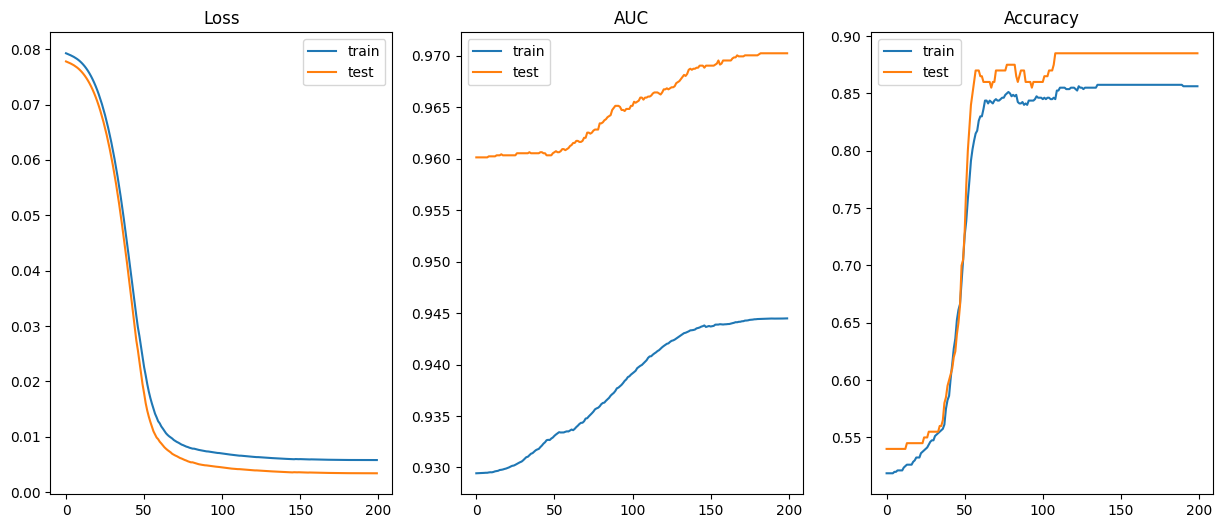

In [5]:
# Plot results
fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(131)
ax.plot(stats_train.losses,label='train')
ax.plot(stats_test.losses,label='test')
ax.set_title('Loss')
ax.legend()

ax = fig.add_subplot(1,3,2)
ax.plot(stats_train.auc_scores,label='train')
ax.plot(stats_test.auc_scores,label='test')
ax.set_title('AUC')
ax.legend()

ax = fig.add_subplot(1,3,3)
ax.plot(stats_train.acc_scores,label='train')
ax.plot(stats_test.acc_scores,label='test')
ax.set_title('Accuracy')
ax.legend()

# Ploting marginal value functions of best model

In [6]:
# Load model from checkpoint
checkpoint = torch.load(PATH)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [7]:


hook = Hook(model.method_instance.monotonic_layer, append_output)
xs = []
with torch.no_grad():
    for i in range(201):
        val = i / 200.0
        x = get_simple_input(val,num_criteria)
        xs.append(val)
        model(x)

outs = np.array(torch.stack(hook.stats)[:, 0].detach().cpu())
# We take every third value becouse the rest are from the normalization layer: velues for 0 and 1
outs = outs[::3] - outs[::3][0]
# Normalize the outputs to get proper weights of the criteria
outs = outs / outs[-1].sum()

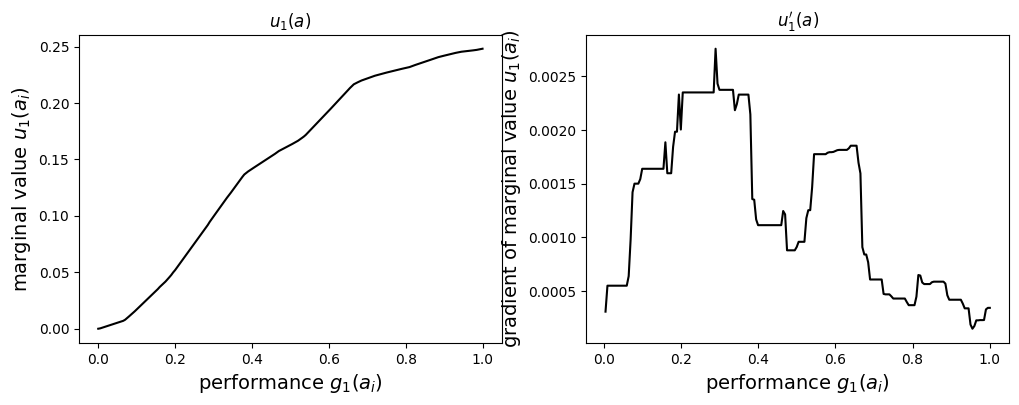

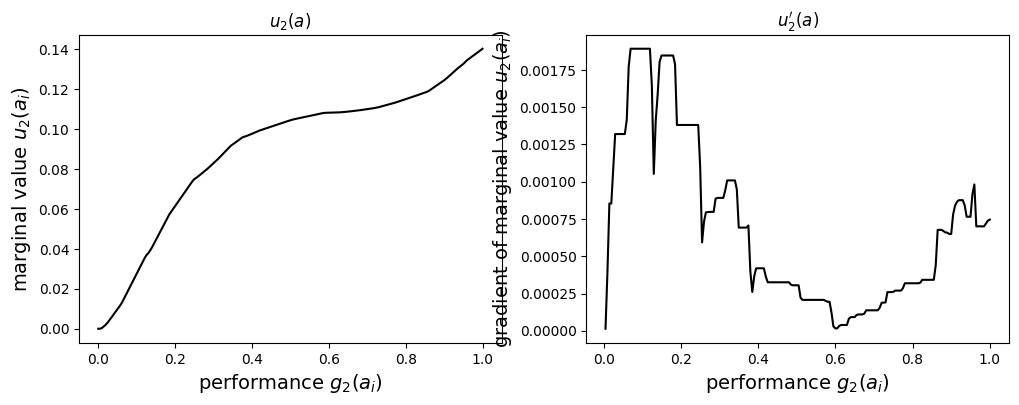

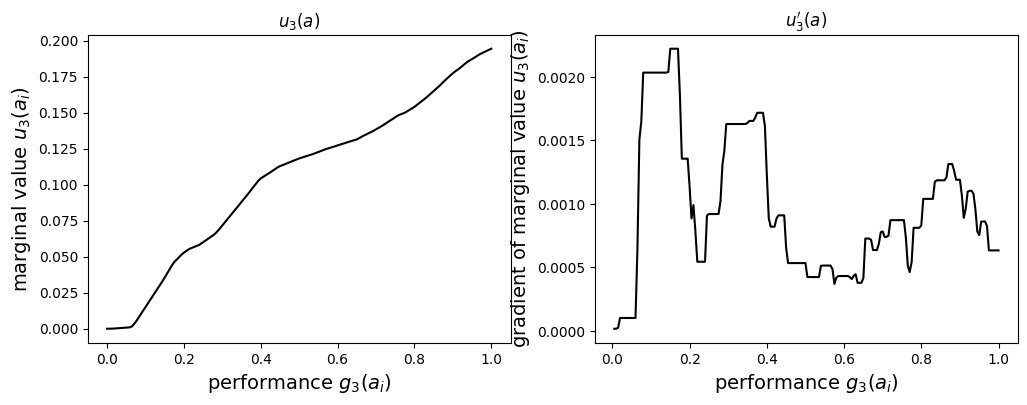

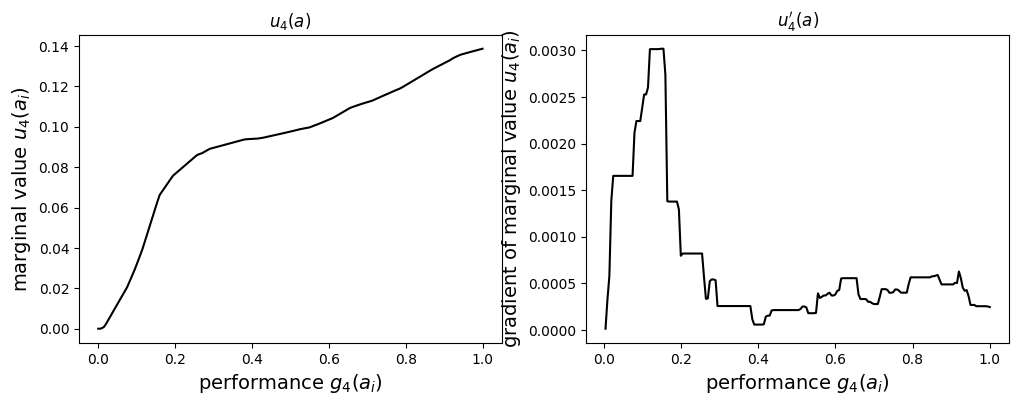

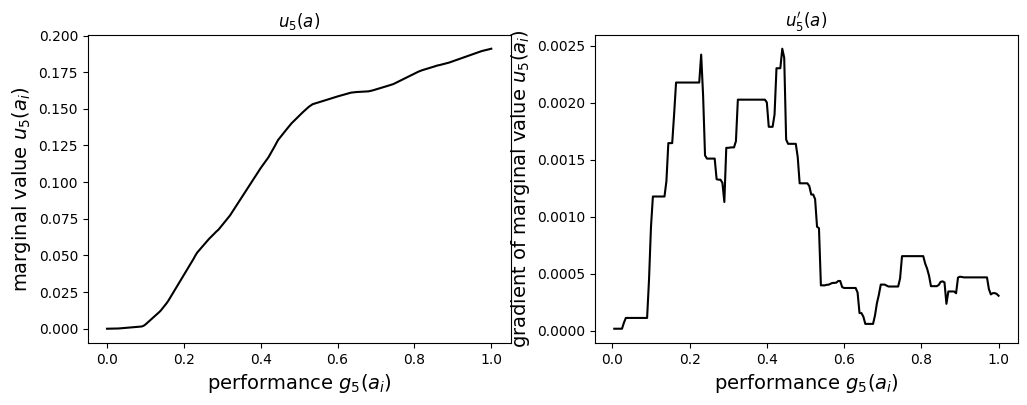

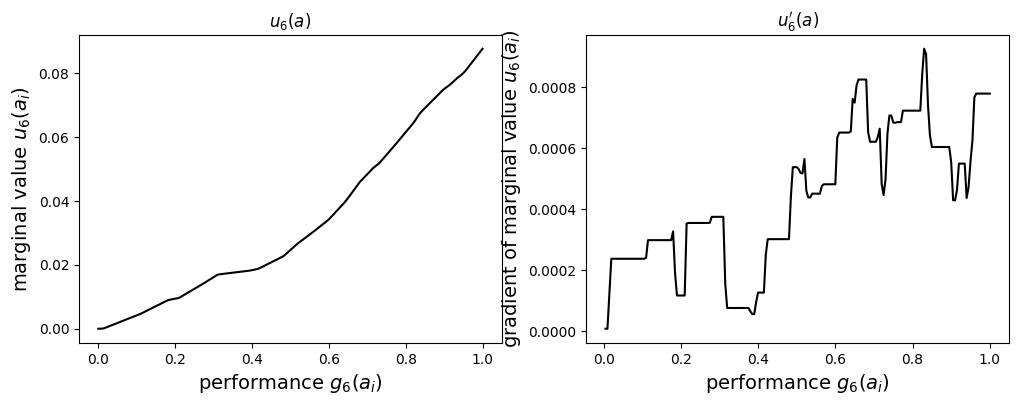

In [8]:
for i in range(num_criteria):
    criterion_number = i + 1
    fig = plt.figure(figsize=(12,4))  
    ax = fig.add_subplot(121)
    ax.set_title(f'$u_{criterion_number}(a)$')
    ax.plot(xs, outs[:, i], color="black")
    ax.set_ylabel(f"marginal value $u_{criterion_number}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{criterion_number}(a_i)$", fontsize=14)

    ax = fig.add_subplot(1,2,2)
    ax.set_title(f"$u_{criterion_number}'(a)$")
    ax.plot(xs[1:], outs[1:, i]-outs[:-1, i], color="black")
    ax.set_ylabel(f"gradient of marginal value $u_{criterion_number}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{criterion_number}(a_i)$", fontsize=14)
    plt.show()